In [1]:
import torch
from torch import nn
from torch.nn import functional as F

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Current device: {device}")

Current device: cuda


In [2]:
# hyper-parameters
num_epochs, lr = 500, 1
num_hiddens = 512
batch_size, num_steps = 32, 35


# 1. Utility Functions

In [3]:
import matplotlib.pyplot as plt
from IPython import display


class AnimatorNoTest:
    """单图实时刷新：适合 RNN 困惑度等只有 train 曲线的场景。"""

    def __init__(self, xlabel='epoch', ylabel=None, xlim=None, ylim=None,
                 legend=None,
                 fmts=('-', 'm--', 'g-.', 'r:', 'c-', 'y--', 'k-.', 'b:'),
                 figsize=(5, 3)):
        self.xlabel = xlabel
        self.ylabel = ylabel
        self.xlim = xlim
        self.ylim = ylim
        self.legend = list(legend) if legend else []
        self.fmts = list(fmts)
        self.X, self.Y = None, None
        self.fig, self.ax = plt.subplots(figsize=figsize)

    @staticmethod
    def _as_lines(values):
        if values is None:
            return []
        if isinstance(values, (list, tuple)):
            return list(values)
        return [values]

    def _ensure_lines(self, n):
        if self.X is None:
            self.X = [[] for _ in range(n)]
            self.Y = [[] for _ in range(n)]
        elif n > len(self.X):
            self.X.extend([] for _ in range(n - len(self.X)))
            self.Y.extend([] for _ in range(n - len(self.Y)))

    def add(self, x, y):
        """追加点并重绘。y 可为标量或与 legend 等长的序列。"""
        y = self._as_lines(y)
        x = self._as_lines(x)
        if len(x) == 1:
            x = x * len(y)
        elif len(x) != len(y):
            raise ValueError(
                f'x 与 y 长度不一致: len(x)={len(x)}, len(y)={len(y)}'
            )
        self._ensure_lines(len(y))
        for i, (xi, yi) in enumerate(zip(x, y)):
            if xi is not None and yi is not None:
                self.X[i].append(xi)
                self.Y[i].append(yi)

        self.ax.cla()
        for i, (xs, ys) in enumerate(zip(self.X, self.Y)):
            fmt = self.fmts[i % len(self.fmts)]
            label = self.legend[i] if i < len(self.legend) else None
            self.ax.plot(xs, ys, fmt, label=label)
        if self.xlim:
            self.ax.set_xlim(self.xlim)
        if self.ylim:
            self.ax.set_ylim(self.ylim)
        if self.xlabel:
            self.ax.set_xlabel(self.xlabel)
        if self.ylabel:
            self.ax.set_ylabel(self.ylabel)
        if self.legend:
            self.ax.legend(self.legend)
        self.ax.grid(True)
        self.fig.tight_layout()
        display.clear_output(wait=True)
        display.display(self.fig)

    def close(self):
        plt.close(self.fig)

In [4]:
import os
import re
import hashlib
from urllib import request

DATA_URL = 'http://d2l-data.s3-accelerate.amazonaws.com/'
DATA_HUB = {
    'time_machine': (DATA_URL + 'timemachine.txt',
                     '090b5e7e70c295757f55df93cb0a180b9691891a')
}

def download(name, cache_dir='./data'):
    """下载 DATA_HUB 中的文件，返回本地路径。"""
    assert name in DATA_HUB, f"{name} 不存在于 {DATA_HUB}"
    url, sha1_hash = DATA_HUB[name]
    os.makedirs(cache_dir, exist_ok=True)
    fname = os.path.join(cache_dir, url.split('/')[-1])
    if os.path.exists(fname):
        sha1 = hashlib.sha1()
        with open(fname, 'rb') as f:
            while True:
                data = f.read(1048576)
                if not data:
                    break
                sha1.update(data)
        if sha1.hexdigest() == sha1_hash:
            return fname
    print(f'正在从 {url} 下载 {fname}...')
    request.urlretrieve(url, fname)
    return fname

def read_time_machine():
    """读取 H.G. Wells《时光机器》，返回预处理后的文本行列表。"""
    with open(download('time_machine'), 'r') as f:
        lines = f.readlines()
    return lines

In [5]:
def tokenize(lines, token='word'):
    """将文本行拆分为单词或字符词元。"""
    lines = [re.sub('[^A-Za-z]+', ' ', line).strip().lower() for line in lines]
    if token == 'word':
        return [line.split() for line in lines]
    elif token == 'char':
        return [list(line) for line in lines]
    else:
        print(f"错误: 未知词元类型: '{token}'")

In [6]:
import collections

def count_corpus(tokens):
    if isinstance(tokens, list):
        tokens = [tk for line in tokens for tk in line]
    return collections.Counter(tokens)

In [7]:
class Vocab:
    """文本词表"""
    def __init__(self, tokens=None, min_freq=0, reserved_tokens=None):
        if tokens is None:
            tokens = []
        if reserved_tokens is None:
            reserved_tokens = []
        # 按出现频率排序
        counter = count_corpus(tokens)
        self._token_freqs = sorted(counter.items(), key=lambda x: x[1],
                                   reverse=True)
        # 未知词元的索引为0
        self.idx_to_token = ['<unk>'] + reserved_tokens
        self.token_to_idx = {token: idx
                             for idx, token in enumerate(self.idx_to_token)}
        for token, freq in self._token_freqs:
            if freq < min_freq:
                break
            if token not in self.token_to_idx:
                self.idx_to_token.append(token)
                self.token_to_idx[token] = len(self.idx_to_token) - 1

    def __len__(self):
        return len(self.idx_to_token)

    def __getitem__(self, tokens):
        if not isinstance(tokens, (list, tuple)):
            return self.token_to_idx.get(tokens, self.unk)
        return [self.__getitem__(token) for token in tokens]

    def to_tokens(self, indices):
        if not isinstance(indices, (list, tuple)):
            return self.idx_to_token[indices]
        return [self.idx_to_token[index] for index in indices]

    @property
    def unk(self):  # 未知词元的索引为0
        return 0

    @property
    def token_freqs(self):
        return self._token_freqs

In [8]:
import random

class SeqDataLoader:
    def __init__(self, batch_size, num_steps, corpus=None, vocab=None, mode='random'):
        assert not (corpus is None or vocab is None)
        self.corpus = corpus
        self.vocab = vocab
        if mode == 'random':
            self.data_iter_fn = self.seq_data_iter_random
        else:
            self.data_iter_fn = self.seq_data_iter_sequential
        self.batch_size = batch_size
        self.num_steps = num_steps
    
    def __iter__(self):
        return self.data_iter_fn(self.corpus, self.batch_size, self.num_steps)
    
    def seq_data_iter_random(self, corpus, batch_size, num_steps):
        corpus = corpus[random.randint(0, num_steps - 1):]
        num_subseqs = (len(corpus) - 1) // num_steps
        initial_indices = list(range(0, num_subseqs * num_steps, num_steps))
        random.shuffle(initial_indices)
        def data(pos):
            # 返回从pos位置开始的长度为num_steps的序列
            return corpus[pos: pos + num_steps]

        num_batches = num_subseqs // batch_size
        for i in range(0, batch_size * num_batches, batch_size):
            # 在这里，initial_indices包含子序列的随机起始索引
            initial_indices_per_batch = initial_indices[i: i + batch_size]
            X = [data(j) for j in initial_indices_per_batch]
            Y = [data(j + 1) for j in initial_indices_per_batch]
            yield torch.tensor(X), torch.tensor(Y)
    
    def seq_data_iter_sequential(self, corpus, batch_size, num_steps):
        offset = random.randint(0, num_steps)
        num_tokens = ((len(corpus) - offset - 1) // batch_size) * batch_size
        Xs = torch.tensor(corpus[offset: offset + num_tokens])
        Ys = torch.tensor(corpus[offset + 1: offset + 1 + num_tokens])
        Xs, Ys = Xs.reshape(batch_size, -1), Ys.reshape(batch_size, -1)
        num_batches = Xs.shape[1] // num_steps
        for i in range(0, num_steps * num_batches, num_steps):
            X = Xs[:, i: i + num_steps]
            Y = Ys[:, i: i + num_steps]
            yield X, Y
        

In [9]:
def normal(shape, device):
    return torch.randn(size=shape, device=device) * 0.01

In [10]:
class Accumulator:
    def __init__(self, num):
        self.data = [0.0] * num
    
    def add(self, *args):
        self.data = [a + float(b) for a, b in zip(self.data, args)]
    
    def reset(self):
        self.data = [0.0] * len(self.data)
    
    def __getitem__(self, idx):
        return self.data[idx]

# 2. Data reloading and preprocessing.

In [11]:
lines = read_time_machine()
tokens_chars = tokenize(lines, 'char')
tokens_words = tokenize(lines, 'word')
for i in range(5):
    print(lines[i*3])
    print(tokens_chars[i*3])
    print(tokens_words[i*3])
    print()

The Time Machine, by H. G. Wells [1898]

['t', 'h', 'e', ' ', 't', 'i', 'm', 'e', ' ', 'm', 'a', 'c', 'h', 'i', 'n', 'e', ' ', 'b', 'y', ' ', 'h', ' ', 'g', ' ', 'w', 'e', 'l', 'l', 's']
['the', 'time', 'machine', 'by', 'h', 'g', 'wells']



[]
[]



[]
[]

was expounding a recondite matter to us. His grey eyes shone and

['w', 'a', 's', ' ', 'e', 'x', 'p', 'o', 'u', 'n', 'd', 'i', 'n', 'g', ' ', 'a', ' ', 'r', 'e', 'c', 'o', 'n', 'd', 'i', 't', 'e', ' ', 'm', 'a', 't', 't', 'e', 'r', ' ', 't', 'o', ' ', 'u', 's', ' ', 'h', 'i', 's', ' ', 'g', 'r', 'e', 'y', ' ', 'e', 'y', 'e', 's', ' ', 's', 'h', 'o', 'n', 'e', ' ', 'a', 'n', 'd']
['was', 'expounding', 'a', 'recondite', 'matter', 'to', 'us', 'his', 'grey', 'eyes', 'shone', 'and']

lights in the lilies of silver caught the bubbles that flashed and

['l', 'i', 'g', 'h', 't', 's', ' ', 'i', 'n', ' ', 't', 'h', 'e', ' ', 'l', 'i', 'l', 'i', 'e', 's', ' ', 'o', 'f', ' ', 's', 'i', 'l', 'v', 'e', 'r', ' ', 'c', 'a', 'u', 'g', 'h', 't', ' ',

In [12]:
vocab = Vocab(tokens_words)
corpus = [vocab[token] for line in tokens_words for token in line]
print(f"Lenth of corpus: {len(corpus)}, lenth of vocab: {len(vocab)}")

Lenth of corpus: 32775, lenth of vocab: 4580


In [13]:
train_iter = SeqDataLoader(batch_size, num_steps, corpus=corpus, vocab=vocab, mode='random')

# 3. Initialization of RNN model

In [14]:
def get_params(vocab_size, num_hiddens, device):
    num_inputs = num_outputs = vocab_size
    
    W_xh = normal((num_inputs, num_hiddens), device)
    W_hh = normal((num_hiddens, num_hiddens), device)
    b_h = torch.zeros(num_hiddens, device=device)
    W_hq = normal((num_hiddens, num_outputs), device)
    b_q = torch.zeros(num_outputs, device=device)
    params = [W_xh, W_hh, b_h, W_hq, b_q]
    for param in params:
        param.requires_grad_(True)
    return params

def init_rnn_state(batch_size, num_hiddens, device):
    return (torch.zeros((batch_size, num_hiddens), device=device),)
    

In [15]:
def rnn(inputs, state, params):
    W_xh, W_hh, b_h, W_hq, b_q = params
    H, = state
    outputs = []
    for X in inputs:
        H = torch.tanh(
            X @ W_xh + 
            H @ W_hh +
            b_h
        )
        Y = H @ W_hq + b_q
        outputs.append(Y)
    return torch.cat(outputs, dim=0), (H,)

In [16]:
class RNNModelScratch:
    def __init__(self, vocab_size, num_hiddens, device, get_params, init_state, forward_fn):
        self.vocab_size, self.num_hiddens, self.init_state, self.forward_fn = vocab_size, num_hiddens, init_state, forward_fn
        self.params = get_params(vocab_size, num_hiddens, device)
    
    def __call__(self, X, state):
        X = F.one_hot(X.T, self.vocab_size).type(torch.float32)
        return self.forward_fn(X, state, self.params)
    
    def begin_state(self, batch_size, device):
        return self.init_state(batch_size, self.num_hiddens, device)

In [17]:
def sgd(params, lr, batch_size):
    for param in params:
        param.data -= lr * param.grad / batch_size
        param.grad.zero_()

In [18]:
def grad_clipping(net, theta):
    if isinstance(net, nn.Module):
        params = [p for p in net.parameters() if p.requires_grad]
    else:
        params = net.params
    norm = torch.sqrt(sum(torch.sum((p.grad**2)) for p in params))
    if norm > theta:
        for param in params:
            param.grad[:] *= theta/norm
    

In [19]:
def predict_rnn(prefix, num_preds, net, vocab, device):
    state = net.begin_state(batch_size=1, device=device)
    outputs = [vocab[prefix[0]]]
    get_input = lambda: torch.tensor([outputs[-1]], device=device).reshape((1, 1))
    for y in prefix[1:]:
        _, state = net(get_input(), state)
        outputs.append(vocab[y])
    for _ in range(num_preds):
        y, state = net(get_input(), state)
        outputs.append(int(y.argmax(dim=1).reshape(1)))
    return ''.join([vocab.idx_to_token[i] + ' ' for i in outputs])

In [20]:
net = RNNModelScratch(len(vocab), num_hiddens, device, get_params, init_rnn_state, rnn)

# 4. Training and prediction.

In [21]:
#try predict a simple sentence
prefix = ['The Time Traveller (for so it will be convenient to speak of him) was expounding a recondite matter to us.']
prefix = tokenize(prefix)
predict_rnn(prefix[0], 20, net, vocab, device)

'the time traveller for so it will be convenient to speak of him was expounding a recondite matter to us recalling awful cause meal creeping particularly ramifications keenest projects flapping type perspective provincial constant mean futile breeding caresses interval filed '

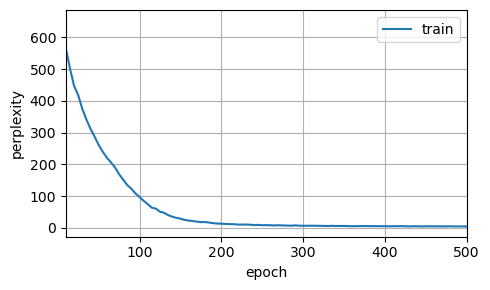

困惑度: 4.9
the time traveller for so it will be convenient to speak of him was expounding a recondite matter to us his grey eyes shone and twinkled and his usually pale face was flushed and animated the fire burned brightly and the soft radiance of the incandescent lights in the lilies of silver caught the bubbles that flashed and passed in our glasses our chairs being his patents embraced he s 


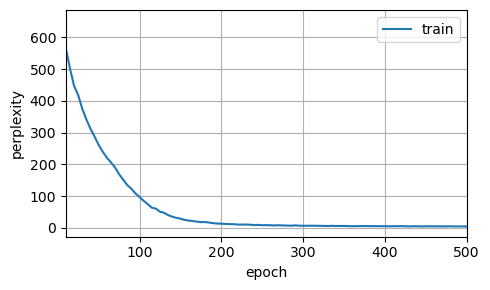

In [22]:
import math

def train_epoch_rnn(net, train_iter, loss, updater, device, use_random_iter):
    state = None
    metric = Accumulator(2)
    for X, y in train_iter:
        if state is None or use_random_iter:
            state = net.begin_state(X.shape[0], device)
        else:
            if isinstance(net, nn.Module) and not isinstance(state, tuple):
                state.detach_()
            else:
                for s in state:
                    s.detach_()
        y = y.T.reshape(-1)
        X, y = X.to(device), y.to(device)
        y_hat, state = net(X, state)
        l = loss(y_hat, y.long()).mean()
        if isinstance(updater, torch.optim.Optimizer):
            updater.zero_grad()
            l.backward()
            grad_clipping(net, 1)
            updater.step()
        else:
            l.backward()
            grad_clipping(net, 1)
            updater(batch_size=1)
        metric.add(l.detach() * y.numel(), y.numel())
    return math.exp(metric[0]/metric[1])

def train_rnn(net, train_iter, vocab, lr, num_epochs, device, use_random_iter=False):
    last_perplexity = float('inf')
    count = 0
    loss = nn.CrossEntropyLoss()
    animator = AnimatorNoTest(
        xlabel='epoch', ylabel='perplexity', legend=['train'], xlim=[10, num_epochs])
    if isinstance(net, nn.Module):
        net = net.to(device)
        updater = torch.optim.SGD(net.parameters(), lr)
    else:
        updater = lambda batch_size: sgd(net.params, lr, batch_size)
    predict = lambda prefix: predict_rnn(prefix, 50, net, vocab, device)
    print_every = max(1, num_epochs // 100)
    for epoch in range(num_epochs):
        perplexity = train_epoch_rnn(net, train_iter, loss, updater, device, use_random_iter)
        if (epoch + 1) % print_every == 0:
            print(f'epoch {epoch + 1}, perplexity {perplexity:.1f}')
            animator.add(epoch + 1, [perplexity])
        if last_perplexity - perplexity < 1e-3 and last_perplexity - perplexity > 0:
            count += 1
            if count >= 5:
                print(f'早停于 epoch {epoch + 1}: 困惑度连续5次下降小于1e-3, 当前 {perplexity:.1f}')
                break
        else:
            count = 0
        last_perplexity = perplexity
    print(f'困惑度: {perplexity:.1f}')
    print(predict(prefix[0]))

train_rnn(net, train_iter, vocab, lr, num_epochs, device)


# 4. Simple implementation of RNN model

In [23]:
rnn_layer = nn.RNN(len(vocab), num_hiddens)
state = torch.zeros((1, batch_size, num_hiddens))

In [24]:
class RNNModel(nn.Module):
    """循环神经网络模型"""
    def __init__(self, rnn_layer, vocab_size, **kwargs):
        super(RNNModel, self).__init__(**kwargs)
        self.rnn = rnn_layer
        self.vocab_size = vocab_size
        self.num_hiddens = self.rnn.hidden_size
        # 如果RNN是双向的（之后将介绍），num_directions应该是2，否则应该是1
        if not self.rnn.bidirectional:
            self.num_directions = 1
            self.linear = nn.Linear(self.num_hiddens, self.vocab_size)
        else:
            self.num_directions = 2
            self.linear = nn.Linear(self.num_hiddens * 2, self.vocab_size)

    def forward(self, inputs, state):
        X = F.one_hot(inputs.T.long(), self.vocab_size)
        X = X.to(torch.float32)
        Y, state = self.rnn(X, state)
        # 全连接层首先将Y的形状改为(时间步数*批量大小,隐藏单元数)
        # 它的输出形状是(时间步数*批量大小,词表大小)。
        output = self.linear(Y.reshape((-1, Y.shape[-1])))
        return output, state

    def begin_state(self, device, batch_size=1):
        if not isinstance(self.rnn, nn.LSTM):
            # nn.GRU以张量作为隐状态
            return  torch.zeros((self.num_directions * self.rnn.num_layers,
                                 batch_size, self.num_hiddens),
                                device=device)
        else:
            # nn.LSTM以元组作为隐状态
            return (torch.zeros((
                self.num_directions * self.rnn.num_layers,
                batch_size, self.num_hiddens), device=device),
                    torch.zeros((
                        self.num_directions * self.rnn.num_layers,
                        batch_size, self.num_hiddens), device=device))

In [25]:
net = RNNModel(rnn_layer, vocab_size=len(vocab))
net = net.to(device)

# 4. Training and prediction.
#try predict a simple sentence
prefix = ['The Time Traveller (for so it will be convenient to speak of him) was expounding a recondite matter to us.']
prefix = tokenize(prefix)
predict_rnn(prefix[0], 20, net, vocab, device)

'the time traveller for so it will be convenient to speak of him was expounding a recondite matter to us unsuspected approaching wrong smote sharer waiting approaching screaming approaching fight screaming approaching screaming approaching screaming approaching screaming approaching screaming approaching '